<a href="https://colab.research.google.com/github/appgallery/Futsal-ML-Analysis/blob/main/New_Futsal_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
# STEP 1 — IMPORT LIBRARIES
import pandas as pd
import numpy as np
import warnings

from collections import defaultdict

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [46]:
# STEP 2 — LOAD MATCH DATASET
MATCH_PATH = "/content/series-futsal-men-matches.csv"

matches_raw = pd.read_csv(MATCH_PATH)

print("Dataset Loaded Successfully")

print("\nShape:")
print(matches_raw.shape)

print("\nColumns:")
print(matches_raw.columns.tolist())

display(matches_raw.head())

Dataset Loaded Successfully

Shape:
(423, 34)

Columns:
['match_id', 'cmp_id', 'homeTeamId', 'awayTeamId', 'startTime', 'endTime', 'startDate', 'startingTime', 'courtId', 'courtName', 'quaterFinal', 'semiFinals', 'final', 'referee_id', 'winningTeam', 'losingTeam', 'winningTeamGoals', 'losingTeamGoals', 'winningTeamPoints', 'losingTeamPoints', 'status', 'round', 'isDraw', 'last_match', 'is_bye', 'note', 'is_forfeited', 'is_cancel', 'homeTeamKits', 'awayTeamKits', 'homeTeamName', 'awayTeamName', 'competitionName', 'seasonName']


,match_id,cmp_id,homeTeamId,awayTeamId,startTime,endTime,startDate,startingTime,courtId,courtName,quaterFinal,semiFinals,final,referee_id,winningTeam,losingTeam,winningTeamGoals,losingTeamGoals,winningTeamPoints,losingTeamPoints,status,round,isDraw,last_match,is_bye,note,is_forfeited,is_cancel,homeTeamKits,awayTeamKits,homeTeamName,awayTeamName,competitionName,seasonName
0,97881,430,331,17,1/20/2023 18:45,1/20/2023 20:00,1/20/2023,18:45:00,11,Series Futsal Arena,NaN,NaN,NaN,1,17,331,5,1,3,0,Completed,1,no,no,False,NaN,False,no,0,0,Hume FC,Fitzroy FC,2023/1 Series Futsal Victoria Men,2023/1
1,97882,430,21,19,1/20/2023 20:00,1/20/2023 21:15,1/20/2023,20:00:00,11,Series Futsal Arena,NaN,NaN,NaN,1,21,19,6,5,0,0,Completed,1,no,no,False,NaN,False,no,0,0,Campbellfield FC,Altona Knights FC,2023/1 Series Futsal Victoria Men,2023/1
2,97883,430,325,18,1/20/2023 21:15,1/20/2023 22:30,1/20/2023,21:15:00,11,Series Futsal Arena,NaN,NaN,NaN,1,18,325,4,1,3,0,Completed,1,no,no,False,NaN,False,no,0,0,Roxburgh Park Gorillas,Moreland Blues FC,2023/1 Series Futsal Victoria Men,2023/1
3,97884,430,22,20,2/21/2023 20:30,2/21/2023 21:45,2/21/2023,20:30:00,11,Series Futsal Arena,NaN,NaN,NaN,1,22,20,2,1,3,0,Completed,1,no,no,False,NaN,False,no,0,0,FC Carlton Heart,Western United FC,2023/1 Series Futsal Victoria Men,2023/1
4,97885,430,22,331,1/27/2023 18:45,1/27/2023 20:00,1/27/2023,18:45:00,11,Series Futsal Arena,NaN,NaN,NaN,1,331,22,4,2,3,0,Completed,2,no,no,False,NaN,False,no,0,0,FC Carlton Heart,Hume FC,2023/1 Series Futsal Victoria Men,2023/1


In [47]:
# STEP 3 — CREATE WORKING COPY
matches = matches_raw.copy()

print("Working dataframe created")

Working dataframe created


In [48]:
# STEP 4 — REMOVE USELESS COLUMNS
drop_cols = [

    'quaterFinal',
    'semiFinals',
    'final',
    'note',

    'startTime',
    'endTime',
    'startingTime',

    'courtId',
    'courtName',

    'referee_id',

    'homeTeamKits',
    'awayTeamKits',

    'competitionName',

    'last_match'
]

existing = [c for c in drop_cols if c in matches.columns]

matches.drop(columns=existing, inplace=True)

print("Dropped Columns:")
print(existing)

print("\nCurrent Shape:")
print(matches.shape)

Dropped Columns:
['quaterFinal', 'semiFinals', 'final', 'note', 'startTime', 'endTime', 'startingTime', 'courtId', 'courtName', 'referee_id', 'homeTeamKits', 'awayTeamKits', 'competitionName', 'last_match']

Current Shape:
(423, 20)


In [49]:
# STEP 5 — CLEAN INVALID MATCHES
matches = matches[
    (matches['is_cancel'] != True) &
    (matches['is_forfeited'] != True)
]

matches = matches[
    matches['status'] == 'Completed'
]

print("Remaining Matches:")
print(matches.shape)

Remaining Matches:
(423, 20)


In [50]:
# STEP 6 — CONVERT DATE & SORT
matches['startDate'] = pd.to_datetime(
    matches['startDate'],
    errors='coerce'
)

matches = matches.sort_values(
    'startDate'
).reset_index(drop=True)

print("Date Converted & Sorted")

print("\nDate Range:")
print(matches['startDate'].min())
print(matches['startDate'].max())

Date Converted & Sorted

Date Range:
2023-01-20 00:00:00
2026-04-26 00:00:00


In [51]:
# # =============================================================================
# # DAYS SINCE LAST MATCH
# # =============================================================================

# matches['home_rest_days'] = 0
# matches['away_rest_days'] = 0

# last_played = {}

# for idx, row in matches.iterrows():

#     date = row['startDate']

#     home = row['homeTeamId']
#     away = row['awayTeamId']

#     # HOME
#     if home in last_played:

#         rest = (
#             date -
#             last_played[home]
#         ).days

#         matches.loc[idx, 'home_rest_days'] = rest

#     else:

#         matches.loc[idx, 'home_rest_days'] = 7


#     # AWAY
#     if away in last_played:

#         rest = (
#             date -
#             last_played[away]
#         ).days

#         matches.loc[idx, 'away_rest_days'] = rest

#     else:

#         matches.loc[idx, 'away_rest_days'] = 7


#     # UPDATE
#     last_played[home] = date
#     last_played[away] = date

# print("Rest Days Feature Created")

In [52]:
# STEP 7 — CLEAN DRAW COLUMN

matches['isDraw'] = matches['isDraw'].map({
    'yes': 1,
    'no': 0
})

print(matches['isDraw'].value_counts())

isDraw
0    402
1     21
Name: count, dtype: int64


In [53]:
# STEP 8 — CREATE TARGET VARIABLE
def create_outcome(row):

    if row['isDraw'] == 1:
        return 2

    elif row['winningTeam'] == row['homeTeamId']:
        return 1

    else:
        return 0


matches['outcome'] = matches.apply(
    create_outcome,
    axis=1
)

print("Outcome Distribution:")
print(matches['outcome'].value_counts())

Outcome Distribution:
outcome
1    211
0    191
2     21
Name: count, dtype: int64


In [54]:
# STEP 9 — CREATE HOME/AWAY GOALS

matches['home_goals'] = np.where(

    matches['winningTeam'] ==
    matches['homeTeamId'],

    matches['winningTeamGoals'],
    matches['losingTeamGoals']
)

matches['away_goals'] = np.where(

    matches['winningTeam'] ==
    matches['awayTeamId'],

    matches['winningTeamGoals'],
    matches['losingTeamGoals']
)

display(
    matches[
        [
            'homeTeamName',
            'awayTeamName',
            'home_goals',
            'away_goals'
        ]
    ].head()
)

,homeTeamName,awayTeamName,home_goals,away_goals
0,Hume FC,Fitzroy FC,1,5
1,Campbellfield FC,Altona Knights FC,6,5
2,Roxburgh Park Gorillas,Moreland Blues FC,1,4
3,FC Carlton Heart,Hume FC,2,4
4,Moreland Blues FC,Altona Knights FC,4,1


In [55]:
# STEP 10 — CREATE FEATURE COLUMNS
feature_cols = [

    # =========================================================
    # STRENGTH FEATURES
    # =========================================================

    'home_win_rate',
    'away_win_rate',

    'home_weighted_form',
    'away_weighted_form',

    'home_attack_strength',
    'away_attack_strength',

    'home_defense_strength',
    'away_defense_strength',

    'home_goal_diff_strength',
    'away_goal_diff_strength',

    # =========================================================
    # STYLE FEATURES
    # =========================================================

    'home_scoring_consistency',
    'away_scoring_consistency',

    'home_clean_sheet_rate',
    'away_clean_sheet_rate',

    'home_high_scoring_rate',
    'away_high_scoring_rate',

    # =========================================================
    # ELO FEATURES
    # =========================================================

    'home_elo',
    'away_elo',

    # =========================================================
    # TACTICAL DIFFERENCES
    # =========================================================

    'diff_form',
    'diff_attack',
    'diff_defense',
    'diff_goal_diff',
    'diff_elo',

    # =========================================================
    # HEAD TO HEAD
    # =========================================================

    'h2h_matches',
    'h2h_home_win_rate',
]

for col in feature_cols:
    matches[col] = 0.0

print("Feature Columns Created")

Feature Columns Created


In [56]:
# STEP 11 — INITIALIZE TEAM MEMORY
INITIAL_ELO = 1500

K_FACTOR = 32

team_memory = {}

print("Team Memory Initialized")

Team Memory Initialized


In [57]:
# STEP 12 — TEAM INITIALIZER FUNCTION
def initialize_team(team_id):

    if team_id not in team_memory:

        team_memory[team_id] = {

            'matches': 0,

            'wins': 0,

            'goals_scored': [],
            'goals_conceded': [],

            'goal_difference': [],

            'results': [],

            'clean_sheets': 0,

            'elo': INITIAL_ELO
        }

print("Initializer Function Ready")

Initializer Function Ready


In [58]:
# STEP 13 — INITIALIZE H2H MEMORY
h2h_memory = defaultdict(lambda: {
    'matches': 0,
    'team1_wins': 0,
    'team2_wins': 0
})

print("H2H Memory Ready")

H2H Memory Ready


In [15]:
# STEP 14 — MAIN FEATURE ENGINEERING LOOP

for idx, row in matches.iterrows():

    # =========================================================
    # BASIC INFO
    # =========================================================

    home = row['homeTeamId']
    away = row['awayTeamId']

    home_goals = row['home_goals']
    away_goals = row['away_goals']

    outcome = row['outcome']


    # =========================================================
    # INITIALIZE TEAMS
    # =========================================================

    initialize_team(home)
    initialize_team(away)

    hs = team_memory[home]
    aws = team_memory[away]


    # =========================================================
    # WIN RATE
    # =========================================================

    home_wr = (
        hs['wins'] / hs['matches']
        if hs['matches'] > 0 else 0
    )

    away_wr = (
        aws['wins'] / aws['matches']
        if aws['matches'] > 0 else 0
    )

    matches.loc[idx, 'home_win_rate'] = home_wr
    matches.loc[idx, 'away_win_rate'] = away_wr


    # =========================================================
    # WEIGHTED RECENT FORM
    # =========================================================

    def weighted_form(results):
      if len(results) == 0:
        return 0

      last5 = results[-5:]

      weights = np.exp(
        np.linspace(0, 1, len(last5)))

      return np.average(last5, weights=weights)

    home_form = weighted_form(hs['results'])
    away_form = weighted_form(aws['results'])

    matches.loc[idx, 'home_weighted_form'] = home_form
    matches.loc[idx, 'away_weighted_form'] = away_form


    # =========================================================
    # ATTACK STRENGTH
    # =========================================================

    home_attack = (
        np.mean(hs['goals_scored'][-5:])
        if len(hs['goals_scored']) > 0 else 0
    )

    away_attack = (
        np.mean(aws['goals_scored'][-5:])
        if len(aws['goals_scored']) > 0 else 0
    )

    matches.loc[idx, 'home_attack_strength'] = home_attack
    matches.loc[idx, 'away_attack_strength'] = away_attack


    # =========================================================
    # DEFENSE STRENGTH
    # LOWER IS BETTER
    # =========================================================

    home_conceded = (
    np.mean(hs['goals_conceded'][-5:])
    if len(hs['goals_conceded']) > 0 else 0)

    away_conceded = (
    np.mean(aws['goals_conceded'][-5:])
    if len(aws['goals_conceded']) > 0 else 0)

    home_def = 1 / (1 + home_conceded)

    away_def = 1 / (1 + away_conceded)

    matches.loc[idx, 'home_defense_strength'] = home_def
    matches.loc[idx, 'away_defense_strength'] = away_def


    # =========================================================
    # GOAL DIFFERENCE STRENGTH
    # =========================================================

    home_gd = (
        np.mean(hs['goal_difference'][-5:])
        if len(hs['goal_difference']) > 0 else 0
    )

    away_gd = (
        np.mean(aws['goal_difference'][-5:])
        if len(aws['goal_difference']) > 0 else 0
    )

    matches.loc[idx, 'home_goal_diff_strength'] = home_gd
    matches.loc[idx, 'away_goal_diff_strength'] = away_gd


    # =========================================================
    # SCORING CONSISTENCY
    # LOWER STD = MORE CONSISTENT
    # =========================================================

    home_consistency = (
        np.std(hs['goals_scored'][-5:])
        if len(hs['goals_scored']) > 1 else 0
    )

    away_consistency = (
        np.std(aws['goals_scored'][-5:])
        if len(aws['goals_scored']) > 1 else 0
    )

    matches.loc[idx, 'home_scoring_consistency'] = home_consistency
    matches.loc[idx, 'away_scoring_consistency'] = away_consistency


    # =========================================================
    # CLEAN SHEET RATE
    # =========================================================

    home_cs = (
        hs['clean_sheets'] / hs['matches']
        if hs['matches'] > 0 else 0
    )

    away_cs = (
        aws['clean_sheets'] / aws['matches']
        if aws['matches'] > 0 else 0
    )

    matches.loc[idx, 'home_clean_sheet_rate'] = home_cs
    matches.loc[idx, 'away_clean_sheet_rate'] = away_cs


    # =========================================================
    # HIGH SCORING RATE
    # =========================================================

    home_high_scoring = (
        np.mean(
            np.array(hs['goals_scored'][-5:]) >= 4
        )
        if len(hs['goals_scored']) > 0 else 0
    )

    away_high_scoring = (
        np.mean(
            np.array(aws['goals_scored'][-5:]) >= 4
        )
        if len(aws['goals_scored']) > 0 else 0
    )

    matches.loc[idx, 'home_high_scoring_rate'] = home_high_scoring
    matches.loc[idx, 'away_high_scoring_rate'] = away_high_scoring


    # =========================================================
    # ELO
    # =========================================================

    home_elo = hs['elo']
    away_elo = aws['elo']

    matches.loc[idx, 'home_elo'] = home_elo
    matches.loc[idx, 'away_elo'] = away_elo


    # =========================================================
    # DIFFERENTIAL FEATURES
    # =========================================================

    matches.loc[idx, 'diff_form'] = (
        home_form - away_form
    )

    matches.loc[idx, 'diff_attack'] = (
        home_attack - away_attack
    )

    matches.loc[idx, 'diff_defense'] = (
        home_def - away_def
    )

    matches.loc[idx, 'diff_goal_diff'] = (
        home_gd - away_gd
    )

    matches.loc[idx, 'diff_elo'] = (
        home_elo - away_elo
    )


    # =========================================================
    # HEAD TO HEAD
    # =========================================================

    pair = tuple(sorted([home, away]))

    h2h = h2h_memory[pair]

    matches.loc[idx, 'h2h_matches'] = h2h['matches']

    if h2h['matches'] > 0:

      if pair[0] == home:

        home_h2h_winrate = (
            h2h['team1_wins'] / h2h['matches']
        )

      else:

        home_h2h_winrate = (
            h2h['team2_wins'] / h2h['matches']
        )

    else:

      home_h2h_winrate = 0.5

    matches.loc[idx, 'h2h_home_win_rate'] = home_h2h_winrate


    # =========================================================
    # ELO CALCULATION
    # =========================================================

    expected_home = (
        1 / (1 + 10 ** ((away_elo - home_elo)/400))
    )

    if outcome == 1:

        actual_home = 1

    elif outcome == 0:

        actual_home = 0

    else:

        actual_home = 0.5

    new_home_elo = (
        home_elo +
        K_FACTOR * (actual_home - expected_home)
    )

    new_away_elo = (
        away_elo +
        K_FACTOR * ((1-actual_home) - (1-expected_home))
    )


    # =========================================================
    # UPDATE TEAM MEMORY
    # =========================================================

    hs['matches'] += 1
    aws['matches'] += 1

    if outcome == 1:

        hs['wins'] += 1

    elif outcome == 0:

        aws['wins'] += 1


    hs['goals_scored'].append(home_goals)
    hs['goals_conceded'].append(away_goals)

    aws['goals_scored'].append(away_goals)
    aws['goals_conceded'].append(home_goals)


    hs['goal_difference'].append(
        home_goals - away_goals
    )

    aws['goal_difference'].append(
        away_goals - home_goals
    )


    # RESULTS

    if outcome == 1:

        hs['results'].append(1)
        aws['results'].append(0)

    elif outcome == 0:

        hs['results'].append(0)
        aws['results'].append(1)

    else:

        hs['results'].append(0.5)
        aws['results'].append(0.5)


    # CLEAN SHEETS

    if away_goals == 0:
        hs['clean_sheets'] += 1

    if home_goals == 0:
        aws['clean_sheets'] += 1


    # UPDATE ELO

    hs['elo'] = new_home_elo
    aws['elo'] = new_away_elo


    # =========================================================
    # UPDATE H2H
    # =========================================================

    h2h['matches'] += 1

    if outcome == 1:
        h2h['team1_wins'] += 1

    elif outcome == 0:
        h2h['team2_wins'] += 1

print("Advanced Tactical Feature Engineering Complete")

Advanced Tactical Feature Engineering Complete


In [16]:
# =============================================================================
# STEP 15 — CREATE ML DATASET ONLY
# =============================================================================

matches_ml = matches.copy()

remove_cols = [

    # TARGET LEAKAGE
    'winningTeam',
    'losingTeam',

    'winningTeamGoals',
    'losingTeamGoals',

    'winningTeamPoints',
    'losingTeamPoints',

    # IDS
    'match_id',
    'cmp_id',

    # TEXT
    'seasonName',

    # META
    'status',
    'is_bye',
    'is_forfeited',
    'is_cancel'
]

existing = [
    c for c in remove_cols
    if c in matches_ml.columns
]

matches_ml.drop(
    columns=existing,
    inplace=True
)

print("ML Dataset Created")
print(matches_ml.shape)

ML Dataset Created
(423, 35)


In [17]:
# =============================================================================
# CREATE HOME/AWAY GOALS
# =============================================================================

matches['home_goals'] = np.where(
    matches['winningTeam'] == matches['homeTeamId'],
    matches['winningTeamGoals'],
    matches['losingTeamGoals']
)

matches['away_goals'] = np.where(
    matches['winningTeam'] == matches['awayTeamId'],
    matches['winningTeamGoals'],
    matches['losingTeamGoals']
)

print(matches[[
    'homeTeamName',
    'awayTeamName',
    'home_goals',
    'away_goals'
]].head())

             homeTeamName       awayTeamName  home_goals  away_goals
0                 Hume FC         Fitzroy FC           1           5
1        Campbellfield FC  Altona Knights FC           6           5
2  Roxburgh Park Gorillas  Moreland Blues FC           1           4
3        FC Carlton Heart            Hume FC           2           4
4       Moreland Blues FC  Altona Knights FC           4           1


In [18]:
# # STEP 15 — REMOVE LEAKAGE COLUMNS
# remove_cols = [

#     # =========================
#     # LEAKAGE
#     # =========================

#     'winningTeam',
#     'losingTeam',

#     'winningTeamGoals',
#     'losingTeamGoals',

#     'winningTeamPoints',
#     'losingTeamPoints',

#     'home_goals',
#     'away_goals',

#     # =========================
#     # IDS
#     # =========================

#     'match_id',
#     'cmp_id',

#     'homeTeamId',
#     'awayTeamId',

#     # =========================
#     # TEXT COLUMNS
#     # =========================

#     'homeTeamName',
#     'awayTeamName',

#     'seasonName',

#     # =========================
#     # META
#     # =========================

#     'status',
#     'is_bye',
#     'is_forfeited',
#     'is_cancel',

#     # =========================
#     # DATE
#     # =========================

#     'startDate'
# ]

# existing = [
#     c for c in remove_cols
#     if c in matches.columns
# ]

# matches.drop(
#     columns=existing,
#     inplace=True
# )

# print("Leakage Columns Removed")

In [19]:
# # STEP 15 — REMOVE LEAKAGE COLUMNS
# leakage_cols = [

#     'winningTeam',
#     'losingTeam',

#     'winningTeamGoals',
#     'losingTeamGoals',

#     'winningTeamPoints',
#     'losingTeamPoints',

#     'home_goals',
#     'away_goals'
# ]

# existing = [
#     c for c in leakage_cols
#     if c in matches.columns
# ]

# matches.drop(columns=existing, inplace=True)

# print("Leakage Removed")

In [20]:
# STEP 16 — FINAL NULL CHECK
nulls = matches.isnull().sum()

nulls = nulls[nulls > 0]

display(nulls)

,0


In [21]:
# # =============================================================================
# # REMOVE INVALID ROWS
# # =============================================================================

# matches = matches.dropna(subset=['outcome'])

# matches = matches.reset_index(drop=True)

# print("Invalid rows removed")

# print(matches.shape)

In [22]:
# STEP 17 — SAVE FINAL FEATURE DATASET
matches_ml.to_csv(
    "advanced_futsal_match_features.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [23]:
# STEP 18 — FINAL DATASET PREVIEW
print("Final Shape:")
print(matches.shape)

print("\nFeature Columns:")
print(feature_cols)

print("\nPreview:")
display(matches.head())

Final Shape:
(423, 48)

Feature Columns:
['home_win_rate', 'away_win_rate', 'home_weighted_form', 'away_weighted_form', 'home_attack_strength', 'away_attack_strength', 'home_defense_strength', 'away_defense_strength', 'home_goal_diff_strength', 'away_goal_diff_strength', 'home_scoring_consistency', 'away_scoring_consistency', 'home_clean_sheet_rate', 'away_clean_sheet_rate', 'home_high_scoring_rate', 'away_high_scoring_rate', 'home_elo', 'away_elo', 'diff_form', 'diff_attack', 'diff_defense', 'diff_goal_diff', 'diff_elo', 'h2h_matches', 'h2h_home_win_rate']

Preview:


,match_id,cmp_id,homeTeamId,awayTeamId,startDate,winningTeam,losingTeam,winningTeamGoals,losingTeamGoals,winningTeamPoints,losingTeamPoints,status,round,isDraw,is_bye,is_forfeited,is_cancel,homeTeamName,awayTeamName,seasonName,outcome,home_goals,away_goals,home_win_rate,away_win_rate,home_weighted_form,away_weighted_form,home_attack_strength,away_attack_strength,home_defense_strength,away_defense_strength,home_goal_diff_strength,away_goal_diff_strength,home_scoring_consistency,away_scoring_consistency,home_clean_sheet_rate,away_clean_sheet_rate,home_high_scoring_rate,away_high_scoring_rate,home_elo,away_elo,diff_form,diff_attack,diff_defense,diff_goal_diff,diff_elo,h2h_matches,h2h_home_win_rate
0,97881,430,331,17,2023-01-20,17,331,5,1,3,0,Completed,1,0,False,False,no,Hume FC,Fitzroy FC,2023/1,0,1,5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.0,1500.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.5
1,97882,430,21,19,2023-01-20,21,19,6,5,0,0,Completed,1,0,False,False,no,Campbellfield FC,Altona Knights FC,2023/1,1,6,5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.0,1500.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.5
2,97883,430,325,18,2023-01-20,18,325,4,1,3,0,Completed,1,0,False,False,no,Roxburgh Park Gorillas,Moreland Blues FC,2023/1,0,1,4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.0,1500.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.5
3,97885,430,22,331,2023-01-27,331,22,4,2,3,0,Completed,2,0,False,False,no,FC Carlton Heart,Hume FC,2023/1,0,2,4,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.166667,0.0,-4.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.0,1484.0,0.0,-1.0,0.833333,4.0,16.0,0.0,0.5
4,97886,430,18,19,2023-01-27,18,19,4,1,3,0,Completed,2,0,False,False,no,Moreland Blues FC,Altona Knights FC,2023/1,1,4,1,1.0,0.0,1.0,0.0,4.0,5.0,0.5,0.142857,3.0,-1.0,0.0,0.0,0.0,0.0,1.0,1.0,1516.0,1484.0,1.0,-1.0,0.357143,4.0,32.0,0.0,0.5


#EDA

In [24]:
# =============================================================================
# STEP 12 — EDA
# =============================================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv(
    "/content/advanced_futsal_match_features.csv"
)

print(df.shape)

df.head()

(423, 35)


,homeTeamId,awayTeamId,startDate,round,isDraw,homeTeamName,awayTeamName,outcome,home_goals,away_goals,home_win_rate,away_win_rate,home_weighted_form,away_weighted_form,home_attack_strength,away_attack_strength,home_defense_strength,away_defense_strength,home_goal_diff_strength,away_goal_diff_strength,home_scoring_consistency,away_scoring_consistency,home_clean_sheet_rate,away_clean_sheet_rate,home_high_scoring_rate,away_high_scoring_rate,home_elo,away_elo,diff_form,diff_attack,diff_defense,diff_goal_diff,diff_elo,h2h_matches,h2h_home_win_rate
0,331,17,2023-01-20,1,0,Hume FC,Fitzroy FC,0,1,5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.0,1500.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.5
1,21,19,2023-01-20,1,0,Campbellfield FC,Altona Knights FC,1,6,5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.0,1500.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.5
2,325,18,2023-01-20,1,0,Roxburgh Park Gorillas,Moreland Blues FC,0,1,4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.0,1500.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.5
3,22,331,2023-01-27,2,0,FC Carlton Heart,Hume FC,0,2,4,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.166667,0.0,-4.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.0,1484.0,0.0,-1.0,0.833333,4.0,16.0,0.0,0.5
4,18,19,2023-01-27,2,0,Moreland Blues FC,Altona Knights FC,1,4,1,1.0,0.0,1.0,0.0,4.0,5.0,0.5,0.142857,3.0,-1.0,0.0,0.0,0.0,0.0,1.0,1.0,1516.0,1484.0,1.0,-1.0,0.357143,4.0,32.0,0.0,0.5


In [25]:
# =============================================================================
# BASIC DATASET INFO
# =============================================================================

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423 entries, 0 to 422
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   homeTeamId                423 non-null    int64  
 1   awayTeamId                423 non-null    int64  
 2   startDate                 423 non-null    object 
 3   round                     423 non-null    int64  
 4   isDraw                    423 non-null    int64  
 5   homeTeamName              423 non-null    object 
 6   awayTeamName              423 non-null    object 
 7   outcome                   423 non-null    int64  
 8   home_goals                423 non-null    int64  
 9   away_goals                423 non-null    int64  
 10  home_win_rate             423 non-null    float64
 11  away_win_rate             423 non-null    float64
 12  home_weighted_form        423 non-null    float64
 13  away_weighted_form        423 non-null    float64
 14  home_attac

In [26]:
# =============================================================================
# CHECK MISSING VALUES
# =============================================================================

nulls = df.isnull().sum()

nulls = nulls[nulls > 0]

print(nulls)

Series([], dtype: int64)


outcome
1    211
0    191
2     21
Name: count, dtype: int64


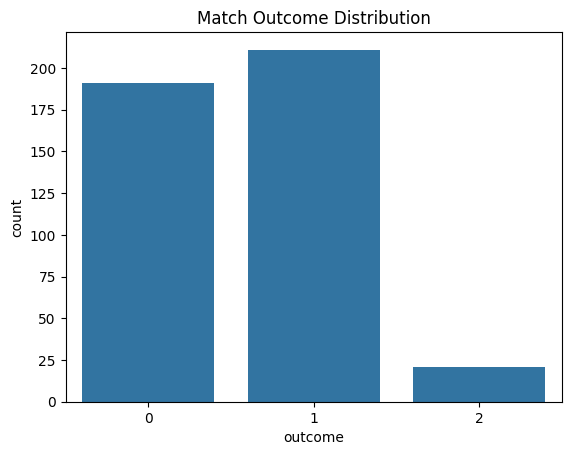

In [27]:
# =============================================================================
# OUTCOME DISTRIBUTION
# =============================================================================

print(df['outcome'].value_counts())

sns.countplot(
    x='outcome',
    data=df
)

plt.title("Match Outcome Distribution")

plt.show()

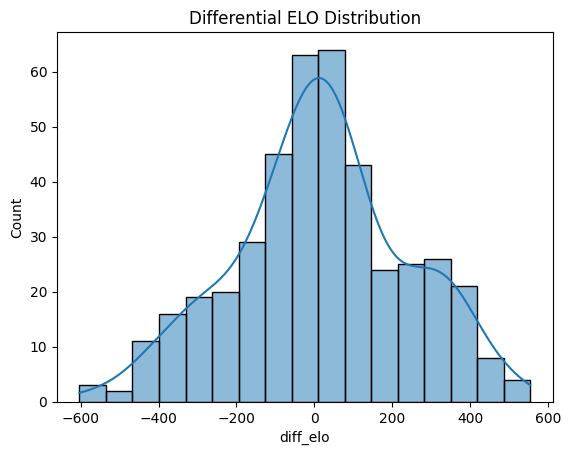

In [28]:
sns.histplot(
    df['diff_elo'],
    kde=True
)

plt.title("Differential ELO Distribution")

plt.show()

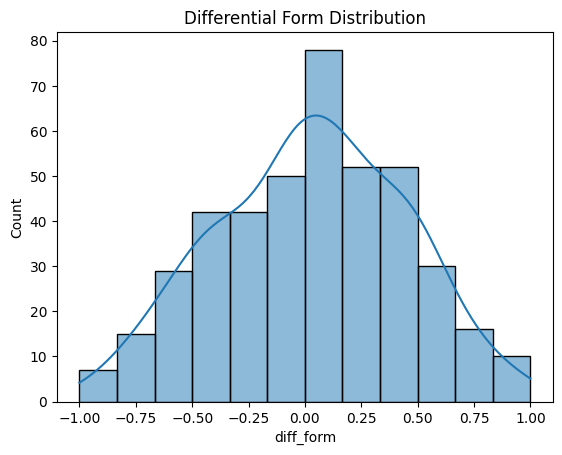

In [29]:
sns.histplot(
    df['diff_form'],
    kde=True
)

plt.title("Differential Form Distribution")

plt.show()

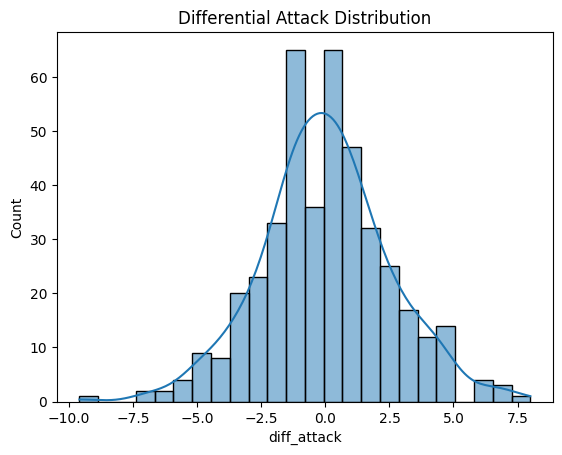

In [30]:
sns.histplot(
    df['diff_attack'],
    kde=True
)

plt.title("Differential Attack Distribution")

plt.show()

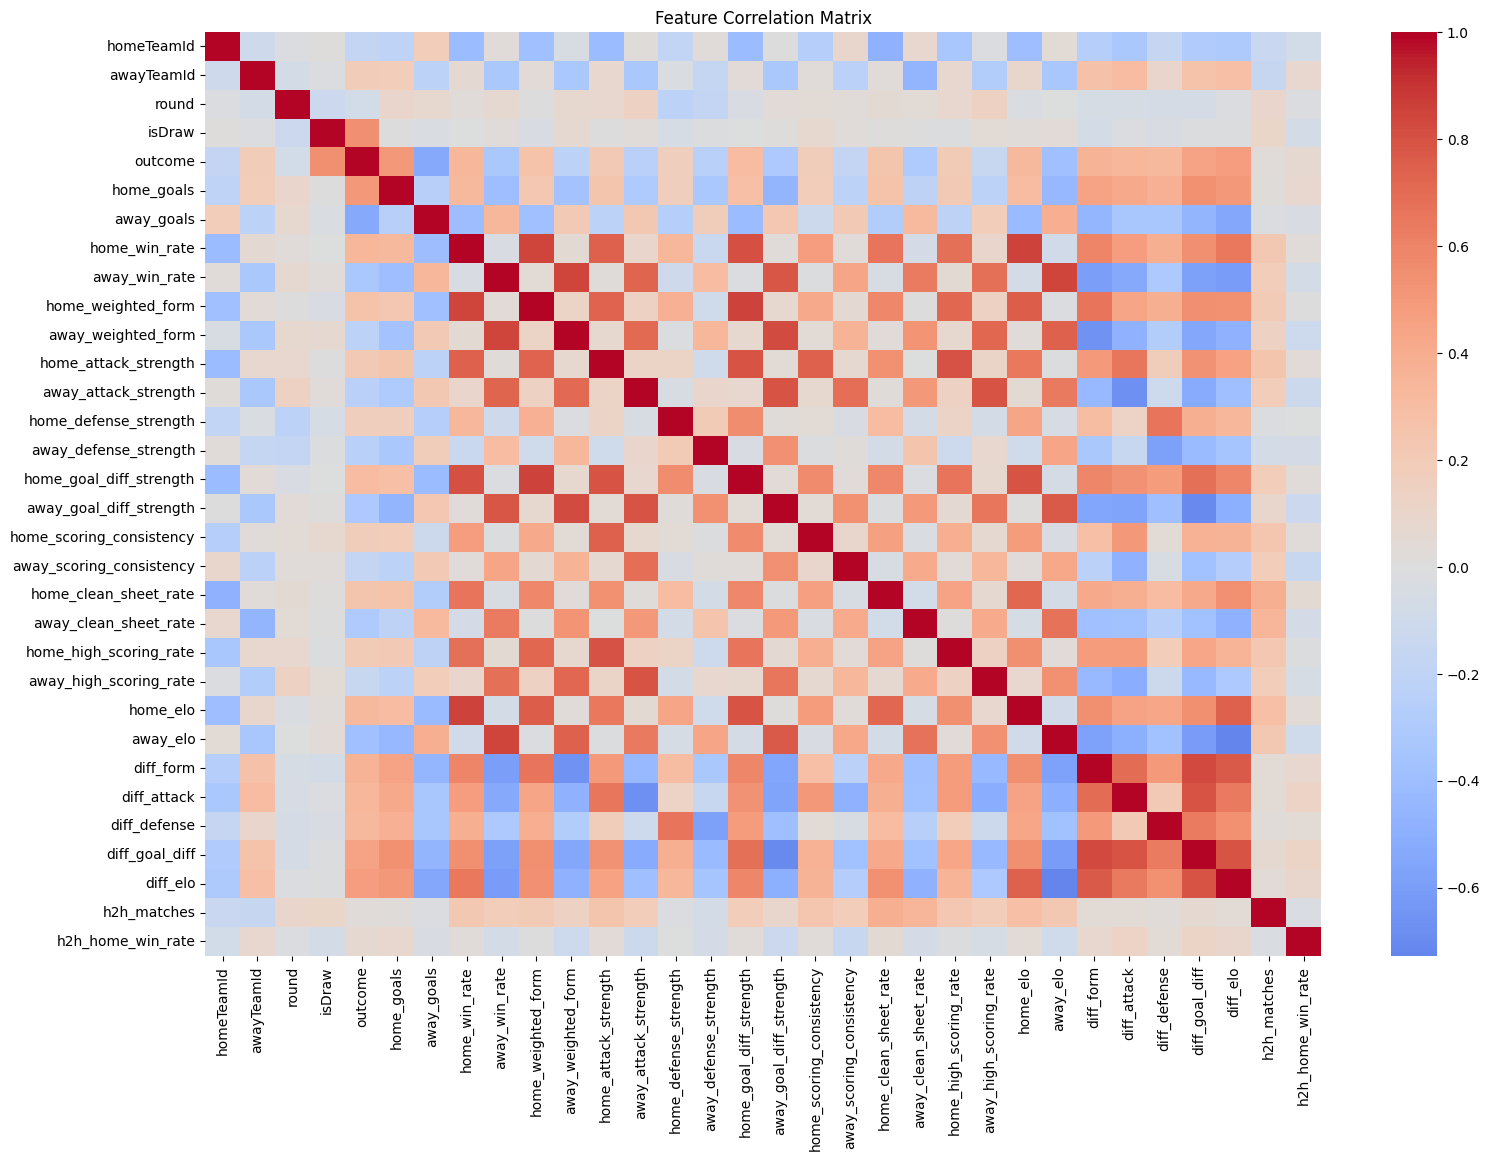

In [31]:
# =============================================================================
# CORRELATION MATRIX
# =============================================================================

corr = df.corr(
    numeric_only=True
)

plt.figure(figsize=(18, 12))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()

In [32]:
# =============================================================================
# CORRELATION WITH OUTCOME
# =============================================================================

target_corr = corr['outcome'].sort_values(
    ascending=False
)

print(target_corr)

outcome                     1.000000
isDraw                      0.549775
home_goals                  0.505113
diff_elo                    0.480013
diff_goal_diff              0.449471
diff_form                   0.364083
diff_attack                 0.338519
home_win_rate               0.333845
diff_defense                0.322552
home_elo                    0.322198
home_goal_diff_strength     0.311030
home_weighted_form          0.264279
home_clean_sheet_rate       0.247953
home_attack_strength        0.213754
home_high_scoring_rate      0.202932
awayTeamId                  0.191974
home_scoring_consistency    0.170476
home_defense_strength       0.168534
h2h_home_win_rate           0.064288
h2h_matches                 0.029997
round                      -0.081698
away_high_scoring_rate     -0.148976
away_scoring_consistency   -0.169819
homeTeamId                 -0.173139
away_weighted_form         -0.219723
away_attack_strength       -0.235780
away_defense_strength      -0.242277
a

# Data Cleaning after EDA

In [33]:
remove_cols = [

    'isDraw',

    'round'
]

df = df.drop(
    columns=remove_cols,
    errors='ignore'
)

In [34]:
df = df[df['outcome'] != 2]

df = df.reset_index(drop=True)

In [35]:
print(df.shape)

print(df['outcome'].value_counts())

(402, 33)
outcome
1    211
0    191
Name: count, dtype: int64


In [61]:
# =============================================================================
# FUNCTION-BASED FUTSAL MATCH PREDICTION PIPELINE
# =============================================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# =============================================================================
# 1. PREPARE DATA
# =============================================================================

def prepare_training_data(feature_df):

    TARGET = 'outcome'

    DROP_COLS = [
    'match_id',
    'startDate',

    'homeTeamName',
    'awayTeamName',

    'homeTeamId',
    'awayTeamId',

    'home_goals',
    'away_goals',

    'outcome'
    ]

    FEATURES = [c for c in feature_df.columns if c not in DROP_COLS]
    # FEATURES = [

    # 'diff_form',
    # 'diff_attack',
    # 'diff_defense',
    # 'diff_goal_diff',
    # 'diff_elo',

    # 'h2h_home_win_rate',

    # 'home_scoring_consistency',
    # 'away_scoring_consistency',

    # 'h2h_matches'
    # ]

    # FEATURES = [

    # 'diff_form',
    # 'diff_attack',
    # 'diff_defense',
    # 'diff_elo',

    # ]

    X = feature_df[FEATURES].copy()
    y = feature_df[TARGET].copy()

    return X, y, FEATURES


# =============================================================================
# 2. TIME-SERIES SPLIT
# =============================================================================

def split_train_test(X, y, split_ratio=0.2):

    split_index = int(len(X) * (1 - split_ratio))

    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]

    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    return X_train, X_test, y_train, y_test


# =============================================================================
# 3. LOGISTIC REGRESSION MODEL
# =============================================================================

def train_logistic_regression(X_train, y_train):

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    return model


# =============================================================================
# 4. RANDOM FOREST MODEL
# =============================================================================

def train_random_forest(X_train, y_train):

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    return model


# =============================================================================
# 5. MODEL EVALUATION
# =============================================================================

def evaluate_model(model, X_test, y_test):

    preds = model.predict(X_test)

    accuracy = accuracy_score(y_test, preds)

    print("=" * 60)
    print("MODEL EVALUATION")
    print("=" * 60)

    print(f"\nAccuracy: {accuracy:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_test, preds))

    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_test, preds))

    return accuracy


# =============================================================================
# 6. FEATURE IMPORTANCE
# =============================================================================

def show_feature_importance(model, feature_names, top_n=15):

    if not hasattr(model, 'feature_importances_'):
        print("Model does not support feature importance")
        return

    import pandas as pd

    fi = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    })

    fi = fi.sort_values(
        'importance',
        ascending=False
    ).reset_index(drop=True)

    print("=" * 60)
    print("TOP FEATURE IMPORTANCE")
    print("=" * 60)

    for i, row in fi.head(top_n).iterrows():

        bar = "█" * int(row['importance'] * 200)

        print(
            f"{i+1:2d}. "
            f"{row['feature']:<35} "
            f"{row['importance']:.4f} "
            f"{bar}"
        )

    return fi


# =============================================================================
# 7. MATCH INFERENCE / PREDICTION
# =============================================================================

def predict_match(model, feature_row):

    probs = model.predict_proba(feature_row)[0]

    prediction = model.predict(feature_row)[0]

    home_prob = probs[1]
    away_prob = probs[0]

    print("=" * 60)
    print("MATCH PREDICTION")
    print("=" * 60)

    print(f"\nHome Win Probability : {home_prob:.2%}")
    print(f"Away Win Probability : {away_prob:.2%}")

    if prediction == 1:
        print("\nPrediction : HOME WIN")
    else:
        print("\nPrediction : AWAY WIN")

    return {
        'home_win_probability': home_prob,
        'away_win_probability': away_prob,
        'prediction': prediction
    }


# =============================================================================
# 8. EXPLAIN MATCH PREDICTION
# =============================================================================

def explain_match(feature_row):

    print("=" * 60)
    print("TACTICAL MATCH ANALYSIS")
    print("=" * 60)

    row = feature_row.iloc[0]

    print("\n--- FORM ---")

    print(
        f"Form Edge: "
        f"{row['diff_form']:.3f}"
    )

    print("\n--- ATTACK ---")

    print(
        f"Attack Edge: "
        f"{row['diff_attack']:.3f}"
    )

    print("\n--- DEFENSE ---")

    print(
        f"Defense Edge: "
        f"{row['diff_defense']:.3f}"
    )

    print("\n--- GOAL DIFFERENCE ---")

    print(
        f"Goal Difference Edge: "
        f"{row['diff_goal_diff']:.3f}"
    )

    print("\n--- ELO STRENGTH ---")

    print(
        f"ELO Edge: "
        f"{row['diff_elo']:.3f}"
    )

    print("\n--- HEAD TO HEAD ---")

    print(
        f"H2H Home Win Rate: "
        f"{row['h2h_home_win_rate']:.2%}"
    )


# =============================================================================
# 9. COMPLETE PIPELINE RUNNER
# =============================================================================

def run_full_pipeline(feature_df):

    print("=" * 60)
    print("PREPARING DATA")
    print("=" * 60)

    X, y, FEATURES = prepare_training_data(feature_df)
    print("Show:",FEATURES)


    print("Total Features:", len(FEATURES))
    print("Dataset Shape:", X.shape)

    # =========================
    # SPLIT
    # =========================

    X_train, X_test, y_train, y_test = split_train_test(X, y)

    print("\nTrain Shape:", X_train.shape)
    print("Test Shape :", X_test.shape)

    # =========================
    # LOGISTIC REGRESSION
    # =========================

    print("\n")
    print("=" * 60)
    print("TRAINING LOGISTIC REGRESSION")
    print("=" * 60)

    lr_model = train_logistic_regression(
        X_train,
        y_train
    )

    lr_acc = evaluate_model(
        lr_model,
        X_test,
        y_test
    )

    # =========================
    # RANDOM FOREST
    # =========================

    print("\n")
    print("=" * 60)
    print("TRAINING RANDOM FOREST")
    print("=" * 60)

    rf_model = train_random_forest(
        X_train,
        y_train
    )

    rf_acc = evaluate_model(
        rf_model,
        X_test,
        y_test
    )

    # =========================
    # BEST MODEL
    # =========================

    if rf_acc >= lr_acc:

        best_model = rf_model
        best_name = "Random Forest"

    else:

        best_model = lr_model
        best_name = "Logistic Regression"

    print("\n")
    print("=" * 60)
    print(f"BEST MODEL: {best_name}")
    print("=" * 60)

    # =========================
    # FEATURE IMPORTANCE
    # =========================

    if best_name == "Random Forest":

        fi = show_feature_importance(
            best_model,
            FEATURES
        )

    else:

        fi = None

    return {
        'best_model': best_model,
        'best_model_name': best_name,
        'features': FEATURES,
        'X_test': X_test,
        'y_test': y_test,
        'feature_importance': fi
    }


# =============================================================================
# 10. RUN EVERYTHING
# =============================================================================

results = run_full_pipeline(df)

PREPARING DATA
Show: ['home_win_rate', 'away_win_rate', 'home_weighted_form', 'away_weighted_form', 'home_attack_strength', 'away_attack_strength', 'home_defense_strength', 'away_defense_strength', 'home_goal_diff_strength', 'away_goal_diff_strength', 'home_scoring_consistency', 'away_scoring_consistency', 'home_clean_sheet_rate', 'away_clean_sheet_rate', 'home_high_scoring_rate', 'away_high_scoring_rate', 'home_elo', 'away_elo', 'diff_form', 'diff_attack', 'diff_defense', 'diff_goal_diff', 'diff_elo', 'h2h_matches', 'h2h_home_win_rate']
Total Features: 25
Dataset Shape: (402, 25)

Train Shape: (321, 25)
Test Shape : (81, 25)


TRAINING LOGISTIC REGRESSION
MODEL EVALUATION

Accuracy: 0.8025

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.78      0.79        40
           1       0.79      0.83      0.81        41

    accuracy                           0.80        81
   macro avg       0.80      0.80      0.80        81
wei

In [37]:
lr_model = results['best_model']

coef_df = pd.DataFrame({
    'feature': results['features'],
    'coef': lr_model.named_steps['model'].coef_[0]
})

coef_df = coef_df.sort_values('coef', ascending=False)

print(coef_df)

        feature      coef
3      diff_elo  1.459087
2  diff_defense  0.297054
1   diff_attack  0.274183
0     diff_form  0.074605


In [38]:
# =============================================================================
# RELOAD ORIGINAL MATCH DATA
# =============================================================================

matches = pd.read_csv("/content/advanced_futsal_match_features.csv")

print(matches.shape)

print(matches.columns)

(423, 35)
Index(['homeTeamId', 'awayTeamId', 'startDate', 'round', 'isDraw', 'homeTeamName', 'awayTeamName', 'outcome', 'home_goals', 'away_goals', 'home_win_rate', 'away_win_rate', 'home_weighted_form',
       'away_weighted_form', 'home_attack_strength', 'away_attack_strength', 'home_defense_strength', 'away_defense_strength', 'home_goal_diff_strength', 'away_goal_diff_strength',
       'home_scoring_consistency', 'away_scoring_consistency', 'home_clean_sheet_rate', 'away_clean_sheet_rate', 'home_high_scoring_rate', 'away_high_scoring_rate', 'home_elo', 'away_elo',
       'diff_form', 'diff_attack', 'diff_defense', 'diff_goal_diff', 'diff_elo', 'h2h_matches', 'h2h_home_win_rate'],
      dtype='object')


In [39]:
# =============================================================================
# BUILD MATCH FEATURE ROW FOR INFERENCE
# =============================================================================

def scoring_consistency(df, team):

    goals = []

    for _, row in df.tail(5).iterrows():

        if row['homeTeamName'] == team:
            goals.append(row['home_goals'])
        else:
            goals.append(row['away_goals'])

    if len(goals) <= 1:
        return 0

    return np.std(goals)


def build_match_features(
    home_team,
    away_team,
    matches,
    feature_columns
):

    latest_date = matches['startDate'].max()

    # =========================================================
    # HOME TEAM HISTORY
    # =========================================================

    home_hist = matches[
        (matches['homeTeamName'] == home_team) |
        (matches['awayTeamName'] == home_team)
    ].sort_values('startDate')

    # =========================================================
    # AWAY TEAM HISTORY
    # =========================================================

    away_hist = matches[
        (matches['homeTeamName'] == away_team) |
        (matches['awayTeamName'] == away_team)
    ].sort_values('startDate')

    # =========================================================
    # BASIC SAFETY
    # =========================================================

    MIN_MATCHES = 3

    if len(home_hist) < MIN_MATCHES:
      print(f"Limited history for {home_team}")

    if len(away_hist) < MIN_MATCHES:
      print(f"Limited history for {away_team}")

    # =========================================================
    # RECENT FORM
    # =========================================================

    def recent_form(df, team):
      last5 = df.tail(5)
      results = []

      for _, row in last5.iterrows():

        if row['homeTeamName'] == team:

            if row['home_goals'] > row['away_goals']:
              results.append(1)

            elif row['home_goals'] == row['away_goals']:
              results.append(0.5)

            else:
              results.append(0)

        else:

            if row['away_goals'] > row['home_goals']:
                results.append(1)
            else:
                results.append(0)

      return np.mean(results)

    # =========================================================
    # GOALS SCORED / CONCEDED
    # =========================================================

    def attack_strength(df, team):

        goals = []

        for _, row in df.tail(5).iterrows():

            if row['homeTeamName'] == team:
                goals.append(row['home_goals'])

            else:
                goals.append(row['away_goals'])

        return np.mean(goals)

    def defense_strength(df, team):

      conceded = []

      for _, row in df.tail(5).iterrows():

        if row['homeTeamName'] == team:
            conceded.append(row['away_goals'])

        else:
            conceded.append(row['home_goals'])

      avg_conceded = np.mean(conceded)

      # MUST MATCH TRAINING LOGIC
      return 1 / (1 + avg_conceded)

    # =========================================================
    # CALCULATE STATS
    # =========================================================

    home_form = recent_form(home_hist, home_team)
    away_form = recent_form(away_hist, away_team)

    home_attack = attack_strength(home_hist, home_team)
    away_attack = attack_strength(away_hist, away_team)

    home_defense = defense_strength(home_hist, home_team)
    away_defense = defense_strength(away_hist, away_team)

    # =========================================================
    # ELO
    # =========================================================


    matches['home_elo'] = matches['home_elo']
    matches['away_elo'] = matches['away_elo']


    latest_home = home_hist.iloc[-1]

    if latest_home['homeTeamName'] == home_team:
      home_elo = latest_home['home_elo']
    else:
      home_elo = latest_home['away_elo']


    latest_away = away_hist.iloc[-1]

    if latest_away['awayTeamName'] == away_team:
      away_elo = latest_away['away_elo']
    else:
      away_elo = latest_away['home_elo']


    # =========================================================
    # HEAD TO HEAD
    # =========================================================

    h2h = matches[
        (
            (matches['homeTeamName'] == home_team) &
            (matches['awayTeamName'] == away_team)
        ) |
        (
            (matches['homeTeamName'] == away_team) &
            (matches['awayTeamName'] == home_team)
        )
    ]

    h2h_matches = len(h2h)

    home_h2h_wins = 0

    for _, row in h2h.iterrows():
        # Use 'outcome' column instead of 'winningTeam'
        if row['homeTeamName'] == home_team: # 'home_team' from function call was the home team in this H2H match
            if row['outcome'] == 1: # Outcome 1 means the home team won in this match row
                home_h2h_wins += 1
        elif row['awayTeamName'] == home_team: # 'home_team' from function call was the away team in this H2H match
            if row['outcome'] == 0: # Outcome 0 means the away team won in this match row
                home_h2h_wins += 1

    if h2h_matches > 0:
        h2h_rate = home_h2h_wins / h2h_matches
    else:
        h2h_rate = 0.5

    # =========================================================
    # FEATURE ROW
    # =========================================================

    row = {

        'home_win_rate': home_form,
        'away_win_rate': away_form,

        'home_weighted_form': home_form,
        'away_weighted_form': away_form,

        'home_attack_strength': home_attack,
        'away_attack_strength': away_attack,

        'home_defense_strength': home_defense,
        'away_defense_strength': away_defense,

        'home_goal_diff_strength': (
            home_attack - home_defense
        ),

        'away_goal_diff_strength': (
            away_attack - away_defense
        ),

        'home_scoring_consistency': scoring_consistency(home_hist, home_team),
        'away_scoring_consistency': scoring_consistency(away_hist, away_team),

        'home_clean_sheet_rate': (
            1 if home_defense < 2 else 0
        ),

        'away_clean_sheet_rate': (
            1 if away_defense < 2 else 0
        ),

        'home_high_scoring_rate': (
            1 if home_attack > 4 else 0
        ),

        'away_high_scoring_rate': (
            1 if away_attack > 4 else 0
        ),

        'home_elo': home_elo / 100,
        'away_elo': away_elo / 100,

        'diff_form': (
            home_form - away_form
        ),

        'diff_attack': (
            home_attack - away_attack
        ),

        'diff_defense': (
            home_defense - away_defense
        ),

        'diff_goal_diff': (
            (home_attack - home_defense) -
            (away_attack - away_defense)
        ),

        'diff_elo': (
            (home_elo - away_elo) / 100
        ),

        'h2h_matches': h2h_matches,

        'h2h_home_win_rate': h2h_rate
    }

    feature_row = pd.DataFrame([row])

    feature_row = feature_row[feature_columns]

    return feature_row

In [59]:
# =============================================================================
# EXAMPLE MATCH PREDICTION
# =============================================================================

best_model = results['best_model']
feature_columns = results['features']

match_features = build_match_features(
    home_team="Hume FC",
    away_team="Melbourne AKU FC",
    matches=matches,
    feature_columns=feature_columns
)


match_features

,diff_form,diff_attack,diff_defense,diff_elo
0,0.6,2.4,0.071429,0.0


In [60]:
# =============================================================================
# PREDICT MATCH
# =============================================================================

prediction = predict_match(
    best_model,
    match_features
)

MATCH PREDICTION

Home Win Probability : 62.94%
Away Win Probability : 37.06%

Prediction : HOME WIN


In [42]:
# =============================================================================
# TACTICAL ANALYSIS
# =============================================================================

# Temporarily add missing features to match_features for explanation purposes.
# These features were removed from the training set and thus from 'feature_columns'
# received by build_match_features, but 'explain_match' still expects them.
# The proper fix would be to either update the 'explain_match' function in cell
# 'm4ndbi_BUNeB' to dynamically only explain features present in 'feature_row',
# or re-include these features in the 'FEATURES' list in 'prepare_training_data'
# in cell 'm4ndbi_BUNeB' and retrain the model.
# Since I am restricted to modifying only this cell, this is a local workaround.

if 'diff_goal_diff' not in match_features.columns:
    match_features['diff_goal_diff'] = 0.0
if 'h2h_home_win_rate' not in match_features.columns:
    match_features['h2h_home_win_rate'] = 0.0

explain_match(match_features)

TACTICAL MATCH ANALYSIS

--- FORM ---
Form Edge: 0.700

--- ATTACK ---
Attack Edge: 0.600

--- DEFENSE ---
Defense Edge: 0.115

--- GOAL DIFFERENCE ---
Goal Difference Edge: 0.000

--- ELO STRENGTH ---
ELO Edge: 0.419

--- HEAD TO HEAD ---
H2H Home Win Rate: 0.00%


In [43]:
print(match_features.T)

                          0
diff_form          0.700000
diff_attack        0.600000
diff_defense       0.114865
diff_elo           0.418665
diff_goal_diff     0.000000
h2h_home_win_rate  0.000000


In [44]:
outcome

0